In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch 

def statistics_gen(total_data, scatter = False, color = False, legend_label = ''): 
    #replace Nan values with 0
    total_data_array = np.nan_to_num(total_data, nan = 0)
    print(total_data_array)

    total_data_array_cum_sum = np.cumsum(total_data_array, axis=1)
    print(total_data_array_cum_sum.shape)
    results_per_sample = np.mean(total_data_array_cum_sum > 0, axis = 0) 
    
    if scatter: 
        if color: 
            plt.scatter(np.arange(len(results_per_sample)),results_per_sample, color = color)
        else: 
            plt.scatter(np.arange(len(results_per_sample)),results_per_sample)
    else:
        if color: 
            plt.plot(results_per_sample, color = color, label=legend_label)
        else: 
            plt.plot(results_per_sample)
                
    return results_per_sample

def restricted_statistics(total_data, filter_data, xlim = None):
    #only get the entries in the total_data for which filter_data is nonzero 
    list_of_lists_filtered = []
    num_batches = len(total_data[0])
    for index in range(len(total_data)):
        sublist = total_data[index]
        filter_sublist = filter_data[index]
        list_of_lists_filtered.append([sublist[subindex] for subindex in range(len(sublist)) if filter_sublist[subindex] > 0])
    
    list_of_lists_filtered_padded = [(sublist + num_batches*[0])[:num_batches] for sublist in list_of_lists_filtered]
    total_data = np.stack(list_of_lists_filtered_padded)
    
    total_data = np.stack(total_data)
    total_data_array = np.array([[0 if x is None else x for x in sublist] for sublist in total_data])
    total_data_array_cum_sum = np.cumsum(total_data_array, axis=1)
    results_per_sample = np.mean(total_data_array_cum_sum > 0, axis = 0) 
    plt.plot(results_per_sample)
    if xlim: 
        plt.xlim(xlim[0], xlim[1])
    return results_per_sample, total_data_array_cum_sum, total_data_array

First, load in and merge the data

In [3]:
def load_and_merge(data_dir, label, total_data = None, num_workers = 100): 
    for worker in range(num_workers): 
        filename = label + '_worker' + str(worker) + '.npy'
        if worker == 0: 
            total_data = np.load(data_dir + '/' + filename)
        else:
            total_data_chunk = np.load(data_dir + '/' + filename)
            #stack data
            total_data = np.vstack((total_data, total_data_chunk))
    
    return total_data
data_dir = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/Result_Data/Fig3'
fb_total_rmsd = load_and_merge(data_dir, label = 'fs_total_rmsd_augvae_nopf_clipped_5_batches_64_evals', num_workers = 99)

Visualization

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
(4523, 6)


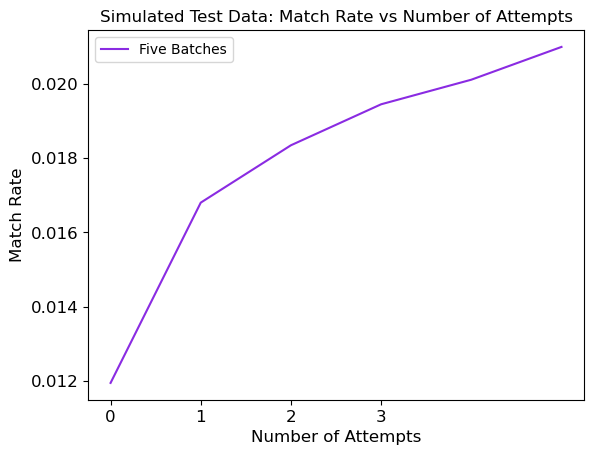

In [4]:
fig, ax = plt.subplots()
title = 'Simulated Test Data: Match Rate vs Number of Attempts' 
defined_spacing= 4 
xlabel='Number of Attempts'
ylabel='Match Rate'
axis_font_size=12

#total_rmsd_results_per_sample = statistics_gen(fs_total_rmsd, color = 'dodgerblue', legend_label = 'Full Set')
total_rmsd_results_per_sample = statistics_gen(fb_total_rmsd, color = 'blueviolet', legend_label = 'Five Batches')

# for i in range(5): 
#     _ = statistics_gen(fb_total_rmsd[int(i*len(fb_total_rmsd)/5):int((i+1)*len(fb_total_rmsd)/5)], scatter = True, color = 'blueviolet')
    
plt.title(title)
plt.xlabel(xlabel, fontsize=axis_font_size)
plt.ylabel(ylabel, fontsize=axis_font_size)
if defined_spacing:
        xmin, xmax = (0, 3)
        plt.xticks(range(int(xmin), int(xmax) + 1, 1))
    
plt.legend()
plt.xticks(fontsize=axis_font_size)
plt.yticks(fontsize=axis_font_size)
plt.show()

fig.savefig(f'/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/Result_Figures/Fig3/{title}{1}.pdf')

In [16]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf'
label = 'RRUFF_data_test_only_using_amcsd'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 64
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)
set_size = len(all_results[0])
total_rmsd, pred_spacegroups, gt_spacegroups = evaluation(all_results, all_gt, recon_file_path, set_size, num_batches = num_batches, traditional_sampling = False , all_results_matrix = True)

100%|██████████| 64/64 [00:03<00:00, 16.91it/s]


[]


0it [00:00, ?it/s]


[True]


100%|██████████| 1/1 [00:00<00:00, 173.73it/s]
/state/partition1/slurm_tmp/24915638.0.0/ipykernel_1155446/905965794.py:213: RuntimeWarning: Mean of empty slice.
  mean_rms_dist = rms_dists[rms_dists != None].mean()


...

[True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, True, True, False, True, True, False, True, True, True, True, True, True, True, True, False, True, False, False, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, False]


100%|██████████| 63/63 [00:00<00:00, 306.76it/s]


[True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, True, True, False, True, True, False, True, True, True, True, True, True, True, True, False, True, False, False, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, False, False]


100%|██████████| 64/64 [00:00<00:00, 337.24it/s]


IndexError: list index out of range

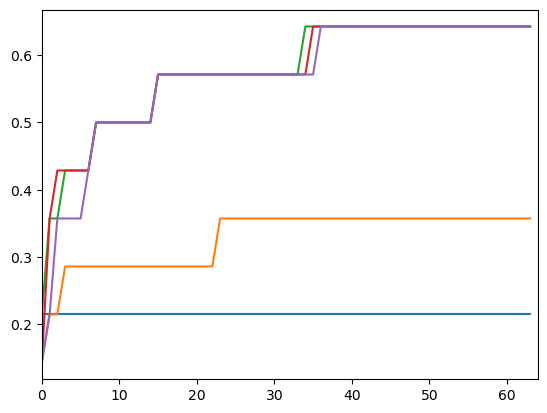

In [17]:
for tol in np.arange(0, 200, 50):
    spacegroup_within_range = (pred_spacegroups <= gt_spacegroups + tol) * (pred_spacegroups >= gt_spacegroups - tol)
    _, _, _  = restricted_statistics(total_rmsd, spacegroup_within_range, xlim = [0,64])
            
total_rmsd_results_per_sample = statistics_gen(total_rmsd)
# _, _, _ = restricted_statistics(total_rmsd, total_spacegroup_stats)

Misclassification analysis

In [122]:
def matched_and_unmatched_compounds(total_data_array, all_results, all_gt): 
    total_matched_compounds = []
    total_unmatched_compounds = []
    for compound_index in range(len(total_data_array)): 
        matched_compounds = [all_results[batch_index][compound_index] for batch_index in range(len(total_data_array[compound_index])) if total_data_array[compound_index][batch_index] >= 0]
        unmatched_compounds = [all_results[batch_index][compound_index] for batch_index in range(len(total_data_array[compound_index])) if total_data_array[compound_index][batch_index] < 0]
        assert (len(matched_compounds) + len(unmatched_compounds)) == len(total_data_array[compound_index])
        
        total_matched_compounds.append(matched_compounds)
        total_unmatched_compounds.append(unmatched_compounds) 
        
    return total_matched_compounds, total_unmatched_compounds

def num_atoms_analysis(matched_pym_strc, unmatched_pym_strc): 
    matched_num_atoms = [strc.num_sites for strc in matched_pym_strc]
    unmatched_num_atoms = [strc.num_sites for strc in unmatched_pym_strc]
    
    return matched_num_atoms, unmatched_num_atoms

def composition_analysis(matched_pym_strc, unmatched_pym_strc): 
    matched_atomic_numbers = [strc.atomic_numbers for strc in matched_pym_strc]
    unmatched_atomic_numbers = [strc.atomic_numbers for strc in unmatched_pym_strc]
    
    matched_atomic_numbers_flattened = []
    unmatched_atomic_numbers_flattened = []
    for entry in matched_atomic_numbers: 
        matched_atomic_numbers_flattened += entry
        
    for entry in unmatched_atomic_numbers: 
        unmatched_atomic_numbers_flattened += entry
    
    return matched_atomic_numbers_flattened, unmatched_atomic_numbers_flattened

def spacegroup_number(structure, symprec = 0.01): 
    sga = SpacegroupAnalyzer(structure, symprec=symprec)
    space_group_number = sga.get_space_group_number()
    return space_group_number

def spacegroup_analysis(matched_pym_strc, unmatched_pym_strc, symprec = 0.01): 
    matched_sgs = [spacegroup_number(structure, symprec) for structure in matched_pym_strc]
    unmatched_sgs = [spacegroup_number(structure, symprec) for structure in unmatched_pym_strc]
    
    return matched_sgs, unmatched_sgs
    
def misclassification_analysis(total_data, all_gt): 
    total_data = np.stack(total_data)
    total_data_array = np.array([[-1 if x is None else x for x in sublist] for sublist in total_data])
    
    total_matched_compounds, total_unmatched_compounds = matched_and_unmatched_compounds(total_data_array, all_gt, all_gt)
    
    #filter out empty lists 
    total_matched_compounds_filtered = [total_matched_compound for total_matched_compound in total_matched_compounds if total_matched_compound != []]
    total_unmatched_compounds_filtered = [total_unmatched_compound for total_unmatched_compound in total_unmatched_compounds if total_unmatched_compound != []]
    
    #create crystal structure objects from the entries
    matched_structures = [Crystal(compound[0]) for compound in total_matched_compounds_filtered]
    unmatched_structures = [Crystal(compound[0]) for compound in total_unmatched_compounds_filtered]
    
    #create pymatgen crystal structures from the entries
    matched_pym_strc = [strc.structure for strc in matched_structures]
    unmatched_pym_strc = [strc.structure for strc in unmatched_structures]
    
    #analyze the num atoms
    matched_num_atoms, unmatched_num_atoms = num_atoms_analysis(matched_pym_strc, unmatched_pym_strc)
    
    #analyze the composition 
    matched_composition, unmatched_composition = composition_analysis(matched_pym_strc, unmatched_pym_strc) 
    
    #analyze the spacegroup 
    matched_sgs, unmatched_sgs = spacegroup_analysis(matched_pym_strc, unmatched_pym_strc) 

    return (matched_structures, unmatched_structures, matched_pym_strc, unmatched_pym_strc, matched_num_atoms, 
            unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs) 

In [135]:
def misclass_plotter(grp1, grp2):
    plt.hist(grp1, bins = 20)
    plt.hist(grp2, alpha = 0.5, bins = 20)
    plt.show()

def visualization(matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs):
    misclass_plotter(matched_num_atoms, unmatched_num_atoms)
    misclass_plotter(matched_composition, unmatched_composition)
    misclass_plotter(matched_sgs, unmatched_sgs)
    
def misclassification_visualization(total_rmsd, all_gt): 
    (_, _, matched_pym, unmatched_pym, matched_num_atoms, unmatched_num_atoms, 
 matched_composition, unmatched_composition, matched_sgs, unmatched_sgs) = misclassification_analysis(total_rmsd, all_gt)
    visualization(matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs)

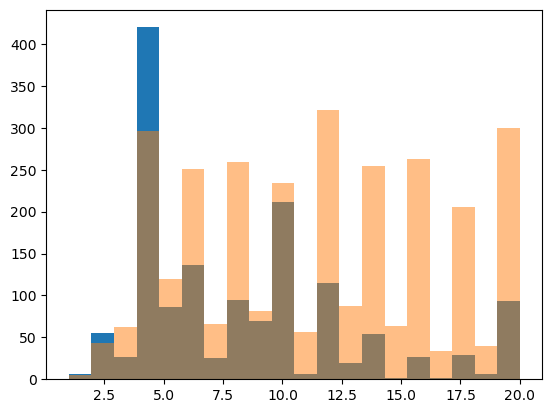

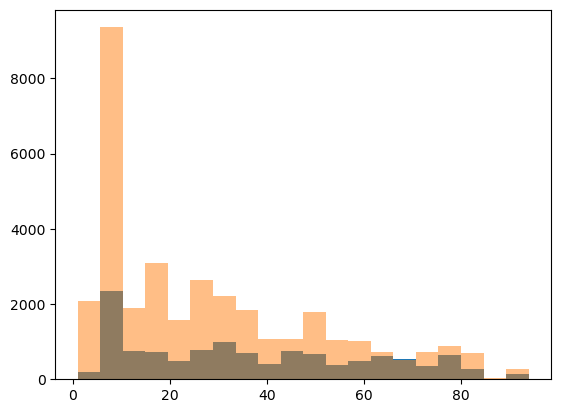

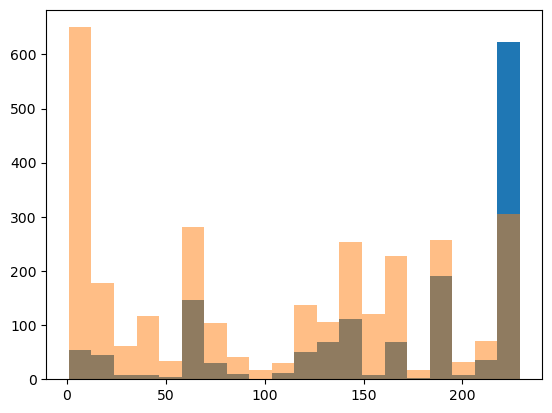

In [136]:
misclassification_visualization(total_rmsd, all_gt)

100%|██████████| 36/36 [00:04<00:00,  8.25it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 117.41it/s]


[True, False, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 86.88it/s]


...

100%|██████████| 36/36 [00:00<00:00, 46.20it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 38.68it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:08<00:00,  4.30it/s]


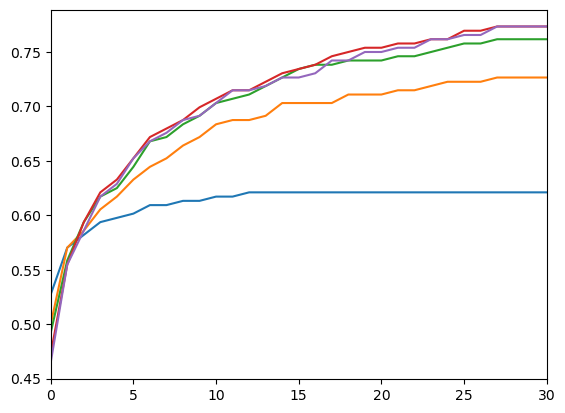

In [92]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-27/pf_noaug'
label = 'sampling5'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 36
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)

total_rmsd, pred_spacegroups, gt_spacegroups = evaluation(all_results, all_gt, recon_file_path, set_size = 256, num_batches = num_batches, traditional_sampling = False , all_results_matrix = True)

for tol in np.arange(0, 200, 50):
    spacegroup_within_range = (pred_spacegroups <= gt_spacegroups + tol) * (pred_spacegroups >= gt_spacegroups - tol)
    _, _, _  = restricted_statistics(total_rmsd, spacegroup_within_range, xlim = [0,30])
            
total_rmsd_results_per_sample = statistics_gen(total_rmsd)
# _, _, _ = restricted_statistics(total_rmsd, total_spacegroup_stats)

I have gotten some strange results from the ground truth crystal structures. I will look into them here

In [16]:
def all_results_retreival(recon_file_path, traditional_sampling = False, num_batches = 1): 
    all_results = []
    all_gt = []
    for eval_num in tqdm(range(num_batches)): 
        file_path = recon_file_path
        if traditional_sampling:
            crys_array_list, true_crystal_array_list, _ = get_crystal_array_list(file_path, batch_idx=eval_num)
        else:
            if eval_num > 0: 
                file_path = file_path[:-3]+ "__{}.pt".format(eval_num - 1)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)
            else: 
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

        all_results.append(crys_array_list)
        all_gt.append(true_crystal_array_list)
    
    return all_results, all_gt

In [18]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-27/nopf_noaug'
recon_file_path = get_file_paths(model_path, 'recon',label='')
num_batches = 30
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches)

100%|██████████| 30/30 [00:03<00:00,  7.86it/s]


In [83]:
def gt_crystal_examination(all_gt, set_size = 256, num_batches = 1):
    gt_crystal_list_one = []
    gt_crystal_list_two = []
    for index in range(set_size):
        for batch_num in range(num_batches - 1): 
            pred_crys = []
            gt_crys_list = []
            try: 
                crystal_match = StructureMatcher(stol=0.5, angle_tol=10, ltol=0.3).get_rms_dist(
                        Crystal(all_gt[batch_num][index]).structure, Crystal(all_gt[batch_num+1][index]).structure)
            except: 
                crystal_match = None

            if crystal_match is None:
                print("not the same") 
                gt_crystal_list_one.append(all_gt[0][index])
                gt_crystal_list_two.append(all_gt[1][index])
            
    return gt_crystal_list_one, gt_crystal_list_two

In [84]:
gt_crystal_list_one, gt_crystal_list_two = gt_crystal_examination(all_gt, set_size = 256, num_batches = 20)

In [85]:
len(gt_crystal_list_one)

0